In [1]:
!pip install nltk scikit-learn tensorflow pandas matplotlib seaborn wordcloud -q

import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [2]:
# Colab cell 1
import pandas as pd

url = "https://raw.githubusercontent.com/Priyanshu-1729/Resume-Screening-using-Python/main/UpdatedResumeDataSet.csv"
df = pd.read_csv(url)

print(df.shape)
print(df['Category'].value_counts())
df.head()

(962, 2)
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad..."


In [3]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', ' ', text)          # URLs remove
    text = re.sub(r'\S+@\S+', ' ', text)                  # emails remove
    text = re.sub(r'[^A-Za-z\s]', ' ', text)               # special chars/numbers remove
    text = re.sub(r'\s+', ' ', text).strip()               # extra whitespace remove
    return text

df['cleaned_text'] = df['Resume'].apply(clean_text)
df[['Resume', 'cleaned_text']].head()

,Resume,cleaned_text
0,Skills * Programming Languages: Python (pandas...,Skills Programming Languages Python pandas num...
1,Education Details \nMay 2013 to May 2017 B.E ...,Education Details May to May B E UIT RGPV Data...
2,"Areas of Interest Deep Learning, Control Syste...",Areas of Interest Deep Learning Control System...
3,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,Skills R Python SAP HANA Tableau SAP HANA SQL ...
4,"Education Details \n MCA YMCAUST, Faridabad...",Education Details MCA YMCAUST Faridabad Haryan...


In [5]:
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: x.lower())

In [6]:
df['tokens'] = df['cleaned_text'].apply(word_tokenize)
df[['cleaned_text', 'tokens']].head()

,cleaned_text,tokens
0,skills programming languages python pandas num...,"[skills, programming, languages, python, panda..."
1,education details may to may b e uit rgpv data...,"[education, details, may, to, may, b, e, uit, ..."
2,areas of interest deep learning control system...,"[areas, of, interest, deep, learning, control,..."
3,skills r python sap hana tableau sap hana sql ...,"[skills, r, python, sap, hana, tableau, sap, h..."
4,education details mca ymcaust faridabad haryan...,"[education, details, mca, ymcaust, faridabad, ..."


In [8]:
stop_words = set(stopwords.words('english'))

df['tokens_no_stop'] = df['tokens'].apply(
    lambda tokens: [w for w in tokens if w not in stop_words and len(w) > 2]
)

In [9]:
lemmatizer = WordNetLemmatizer()

df['final_tokens'] = df['tokens_no_stop'].apply(
    lambda tokens: [lemmatizer.lemmatize(w) for w in tokens]
)

df['final_text'] = df['final_tokens'].apply(lambda tokens: ' '.join(tokens))
df[['Resume', 'final_text']].head()

,Resume,final_text
0,Skills * Programming Languages: Python (pandas...,skill programming language python panda numpy ...
1,Education Details \nMay 2013 to May 2017 B.E ...,education detail may may uit rgpv data scienti...
2,"Areas of Interest Deep Learning, Control Syste...",area interest deep learning control system des...
3,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skill python sap hana tableau sap hana sql sap...
4,"Education Details \n MCA YMCAUST, Faridabad...",education detail mca ymcaust faridabad haryana...


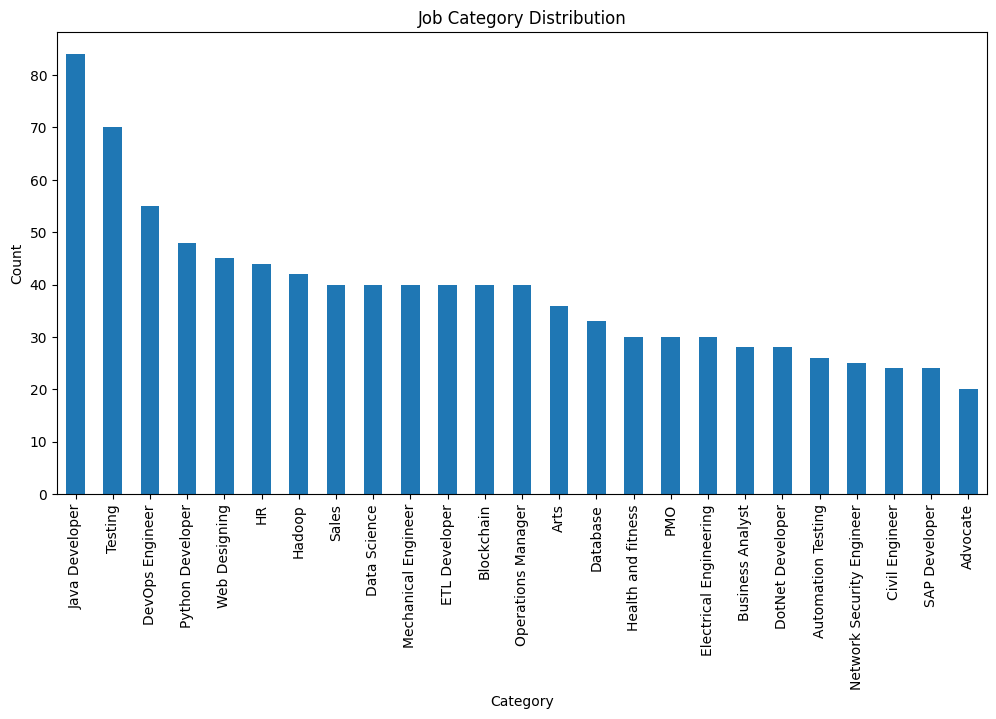

In [10]:
# Class distribution
plt.figure(figsize=(12,6))
df['Category'].value_counts().plot(kind='bar')
plt.title('Job Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

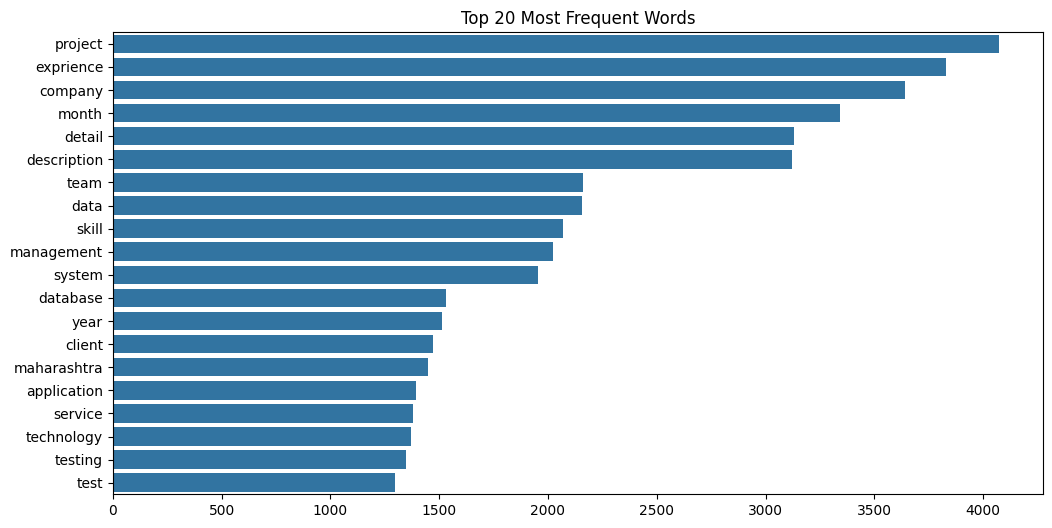

In [11]:
# Most frequent words - overall
from collections import Counter
all_words = [word for tokens in df['final_tokens'] for word in tokens]
word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

words, counts = zip(*top_20)
plt.figure(figsize=(12,6))
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 20 Most Frequent Words')
plt.show()

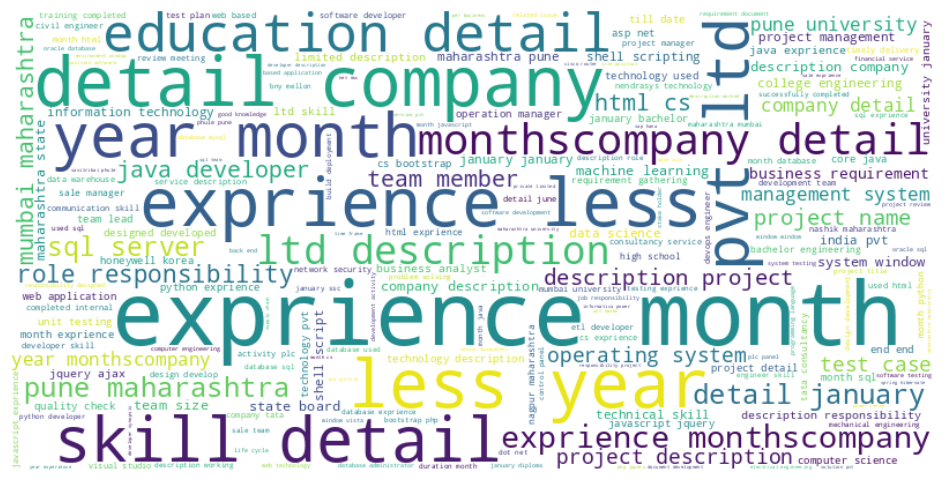

In [12]:
wc = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_words))
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [13]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])


class_names = le.classes_
print(class_names)

['Advocate' 'Arts' 'Automation Testing' 'Blockchain' 'Business Analyst'
 'Civil Engineer' 'Data Science' 'Database' 'DevOps Engineer'
 'DotNet Developer' 'ETL Developer' 'Electrical Engineering' 'HR' 'Hadoop'
 'Health and fitness' 'Java Developer' 'Mechanical Engineer'
 'Network Security Engineer' 'Operations Manager' 'PMO' 'Python Developer'
 'SAP Developer' 'Sales' 'Testing' 'Web Designing']


In [14]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['final_text'], df['label'],
    test_size=0.2, random_state=42, stratify=df['label']
)

In [15]:
count_vectorizer = CountVectorizer(max_features=5000)
X_train_bow = count_vectorizer.fit_transform(X_train_text)
X_test_bow = count_vectorizer.transform(X_test_text)

print(X_train_bow.shape, X_test_bow.shape)

(769, 5000) (193, 5000)


In [16]:
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

y_pred_nb = nb_model.predict(X_test_bow)

# Metrics
nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='macro', zero_division=0)
nb_recall = recall_score(y_test, y_pred_nb, average='macro', zero_division=0)
nb_f1 = f1_score(y_test, y_pred_nb, average='macro', zero_division=0)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")
print(f"Naive Bayes Precision (macro): {nb_precision:.4f}")
print(f"Naive Bayes Recall (macro): {nb_recall:.4f}")
print(f"Naive Bayes F1-Score (macro): {nb_f1:.4f}")

print("\nClassification Report:\n", classification_report(y_test, y_pred_nb, target_names=class_names, zero_division=0))

Naive Bayes Accuracy: 0.9793
Naive Bayes Precision (macro): 0.9851
Naive Bayes Recall (macro): 0.9775
Naive Bayes F1-Score (macro): 0.9794

Classification Report:
                            precision    recall  f1-score   support

                 Advocate       1.00      0.75      0.86         4
                     Arts       0.88      1.00      0.93         7
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       0.86      1.00      0.92         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering      

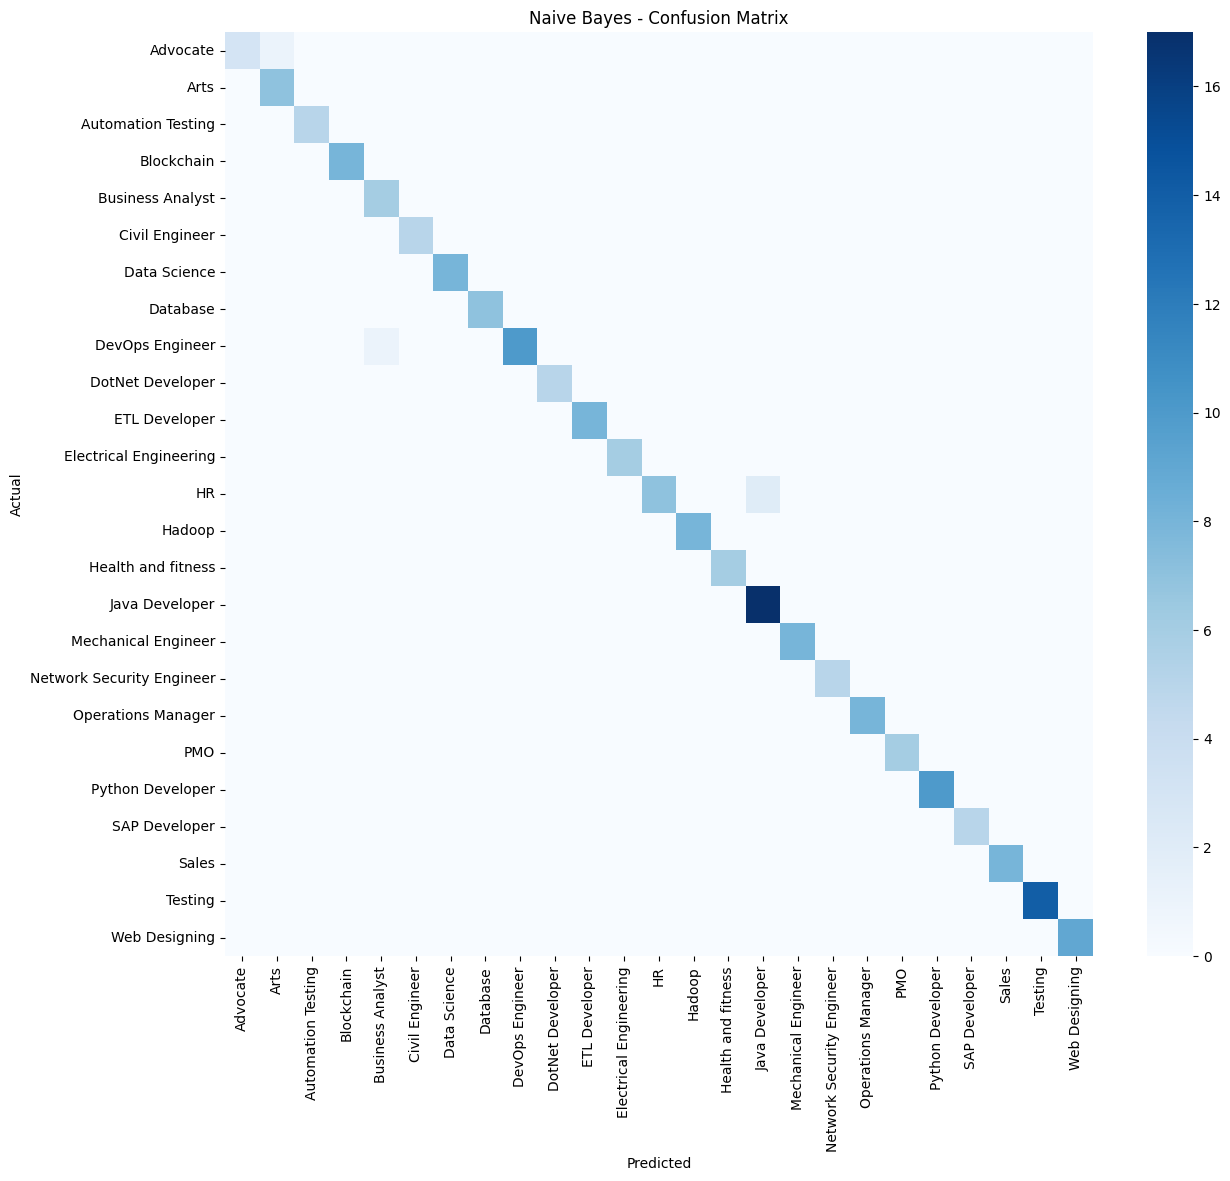

In [17]:
# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(14,12))
sns.heatmap(cm_nb, annot=False, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Naive Bayes - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [18]:
MAX_VOCAB = 5000
MAX_LEN = 200

tokenizer_dl = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(X_train_text)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train_text)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

num_classes = len(class_names)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print(X_train_pad.shape, X_test_pad.shape)

(769, 200) (193, 200)


In [19]:
cnn_model = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=128, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = cnn_model.fit(
    X_train_pad, y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.1561 - loss: 3.1200 - val_accuracy: 0.2078 - val_loss: 2.9897
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.3324 - loss: 2.7774 - val_accuracy: 0.3636 - val_loss: 2.6107
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.4986 - loss: 2.2484 - val_accuracy: 0.7403 - val_loss: 1.9880
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.7370 - loss: 1.5654 - val_accuracy: 0.8182 - val_loss: 1.3152
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.8801 - loss: 0.9262 - val_accuracy: 0.9351 - val_loss: 0.7008
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - accuracy: 0.9422 - loss: 0.4679 - val_accuracy: 0.9351 - val_loss: 0.3526
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.9697 - loss: 0.2524 - val_accuracy: 0.9740 - val_loss: 0.1778
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9913 - loss: 0.1383 - val_accuracy: 0.9870 -

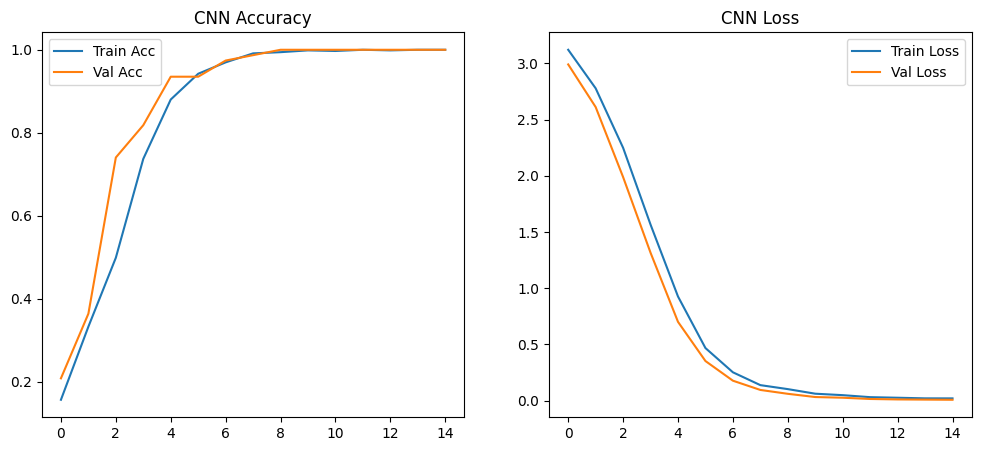

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('CNN Loss')
plt.legend()

plt.show()

In [22]:
y_pred_cnn_probs = cnn_model.predict(X_test_pad)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)
y_true_cnn = np.argmax(y_test_cat, axis=1)

cnn_accuracy = accuracy_score(y_true_cnn, y_pred_cnn)
cnn_precision = precision_score(y_true_cnn, y_pred_cnn, average='macro', zero_division=0)
cnn_recall = recall_score(y_true_cnn, y_pred_cnn, average='macro', zero_division=0)
cnn_f1 = f1_score(y_true_cnn, y_pred_cnn, average='macro', zero_division=0)

print(f"CNN Accuracy: {cnn_accuracy:.4f}")
print(f"CNN Precision (macro): {cnn_precision:.4f}")
print(f"CNN Recall (macro): {cnn_recall:.4f}")
print(f"CNN F1-Score (macro): {cnn_f1:.4f}")

print("\nClassification Report:\n", classification_report(y_true_cnn, y_pred_cnn, target_names=class_names, zero_division=0))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
CNN Accuracy: 0.9948
CNN Precision (macro): 0.9943
CNN Recall (macro): 0.9964
CNN F1-Score (macro): 0.9950

Classification Report:
                            precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       0.86      1.00      0.92         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering

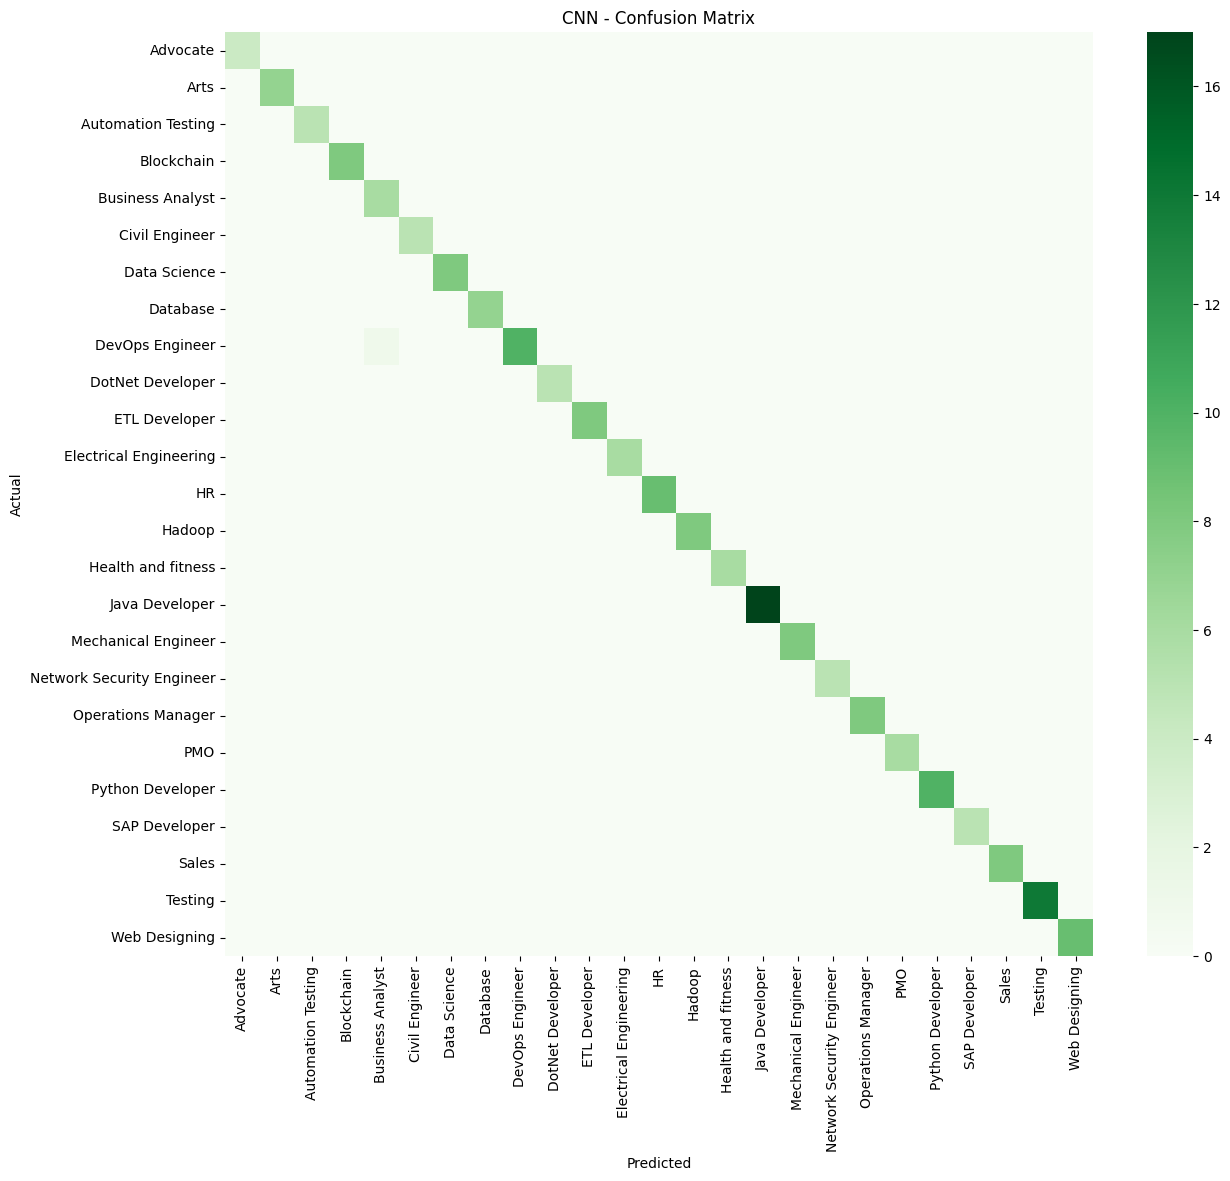

In [23]:
# Confusion Matrix - CNN
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(14,12))
sns.heatmap(cm_cnn, annot=False, cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('CNN - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [24]:
results_df = pd.DataFrame({
    'Model': ['Naive Bayes', 'CNN'],
    'Accuracy': [nb_accuracy, cnn_accuracy],
    'Precision (macro)': [nb_precision, cnn_precision],
    'Recall (macro)': [nb_recall, cnn_recall],
    'F1-Score (macro)': [nb_f1, cnn_f1]
})

print(results_df)
results_df.to_csv('member2_results.csv', index=False)

         Model  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
0  Naive Bayes  0.979275           0.985075        0.977475          0.979415
1          CNN  0.994819           0.994286        0.996364          0.995018


In [25]:
import joblib

joblib.dump(nb_model, 'naive_bayes_model.pkl')
joblib.dump(count_vectorizer, 'count_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')

cnn_model.save('cnn_model.h5')

import pickle
with open('cnn_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer_dl, f)


from google.colab import files
files.download('naive_bayes_model.pkl')
files.download('count_vectorizer.pkl')
files.download('label_encoder.pkl')
files.download('cnn_model.h5')
files.download('cnn_tokenizer.pkl')
files.download('member2_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>